In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
root_dir = Path("../../../class.vision/")

In [3]:
with open(root_dir / "model/tensorflow/object_detection_classes_coco.txt") as f :
    classes = f.read().strip().split("\n")

print("len:", len(classes), "last:", classes[-1])

len: 90 last: toothbrush


In [4]:
colors = [
    (255, 0, 0),     # Blue
    (0, 255, 0),     # Green
    (0, 0, 255),     # Red
    (255, 255, 0),   # Cyan
    (255, 0, 255),   # Magenta
    (0, 255, 255),   # Yellow
    (128, 0, 0),     # Dark Blue
    (0, 128, 0),     # Dark Green
    (0, 0, 128),     # Dark Red
    (200, 200, 200)  # Light Gray
]

In [5]:
def img_blob(image):
    return cv.dnn.blobFromImage(image, size=(300,300), crop=False, swapRB=True)

In [6]:
class DetectionObj:
    label = 1
    confidence = 2
    x1 = 3
    y1 = 4
    x2 = 5
    y2 = 6

    def __init__(self, detection):
        self.label = int(detection[DetectionObj.label])
        self.confidence = float(detection[DetectionObj.confidence])
        self.x1 = float(detection[DetectionObj.x1])
        self.y1 = float(detection[DetectionObj.y1])
        self.x2 = float(detection[DetectionObj.x2])
        self.y2 = float(detection[DetectionObj.y2])

    def get_bbox(self, w, h):
        pt1 = int(self.x1 * w), int(self.y1 * h)
        pt2 = int(self.x2 * w), int(self.y2 * h)
        return pt1, pt2

    def get_class(self):
        return classes[self.label-1]

def annotate(img, detection: DetectionObj, color=(255, 0, 0)):
    height, width = img.shape[:2]
    pt1, pt2 = detection.get_bbox(width, height)
    cv.rectangle(img, pt1, pt2, color, 2)
    cv.putText(img, detection.get_class() + f" {detection.confidence*100:0.0f}", pt1, cv.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

def filter_detections(detections, threshold):
    return detections[detections[..., DetectionObj.confidence] > threshold]

In [7]:
model = cv.dnn.readNetFromTensorflow(root_dir/'model/tensorflow/frozen_inference_graph.pb', root_dir/'model/tensorflow/ssd_mobilenet_v2_coco_2018_03_29.pbtxt')

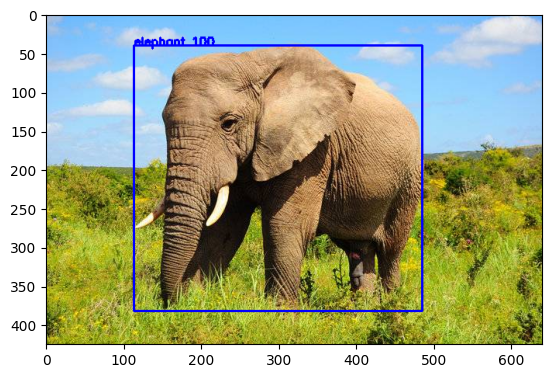

In [8]:
image = cv.imread(root_dir / "images/elephant.jpg")

model.setInput(img_blob(image))
detections = model.forward()
detections = filter_detections(detections, 0.3)

draw_img = image.copy()

for d in detections:
    detection = DetectionObj(d)
    annotate(draw_img, detection)

plt.imshow(draw_img[...,::-1]); plt.title("");

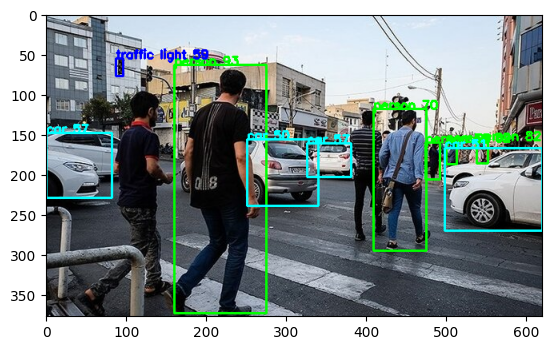

In [9]:
image = cv.imread(root_dir / "images/pedestrian.jpg")

model.setInput(img_blob(image))
detections = model.forward()
detections = filter_detections(detections, 0.5)

draw_img = image.copy()

for d in detections:
    detection = DetectionObj(d)
    annotate(draw_img, detection, colors[detection.label % len(colors)])

plt.subplot(); plt.imshow(draw_img[...,::-1]); plt.title("");